# Fault Network System Analysis

In this notebook we will import logs from collector and gateway devices, analyze them and train model to detect anomalies and classify data.

## Libraries

We import necessary python libraries.

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Data import

First, we need to import data that have been already parsed for our needs.

In [29]:
collector_data = pd.read_csv('data.csv')
gateway_data = pd.read_csv('gateway_logs.txt')

## Dataset

Collector dataset:

* ```date``` - date of log
* ```timestamp``` - timestamp of log
* ```id``` - log id
* ```seq``` - packet sequence number
* ```rtt``` - round-trip time (time diffrence between request and reply)
* ```iat``` - inter-arrival time (time diffrence between packets)
* ```length``` - number of bits in packet
* ```seq_difference``` - sequence difference between following packets
* ```session_start``` - flag representing start of new session
* ```has_reply``` - flag indicating if request had reply

<br>

Gateway dataset:

* ```start_date``` - start date of action
* ```end_date``` - end date of action
* ```action``` - categorized traffic control action

## Merging datasets

Our sets look like this.

In [30]:
collector_data.head(10)

,date,timestamp,id,seq,rtt,iat,length,seq_difference,session_start,has_reply
0,2026-03-23,09:55:28.907189,10,0,0.000016,0.000000,64,1,0,1
1,2026-03-23,09:55:29.107331,10,1,0.000016,0.200142,64,1,0,1
2,2026-03-23,09:55:29.307475,10,2,0.000018,0.200144,64,1,0,1
3,2026-03-23,09:55:29.507608,10,3,0.000016,0.200133,64,1,0,1
4,2026-03-23,09:55:29.707735,10,4,0.000016,0.200127,64,1,0,1
5,2026-03-23,09:55:29.907865,10,5,0.000017,0.200130,64,1,0,1
6,2026-03-23,09:55:30.107983,10,6,0.000018,0.200118,64,1,0,1
7,2026-03-23,09:55:30.308103,10,7,0.000015,0.200120,64,1,0,1
8,2026-03-23,09:55:30.508218,10,8,0.000027,0.200115,64,1,0,1
9,2026-03-23,09:55:30.708369,10,9,0.000015,0.200151,64,1,0,1


In [31]:
gateway_data.head(10)

,start_date,end_date,action
0,2026-03-23 09:55:21,2026-03-23 09:55:31,NORMAL
1,2026-03-23 09:55:31,2026-03-23 09:55:41,NORMAL
2,2026-03-23 09:55:41,2026-03-23 09:55:51,NORMAL
3,2026-03-23 09:55:51,2026-03-23 09:56:01,NORMAL
4,2026-03-23 09:56:01,2026-03-23 09:56:11,NORMAL
5,2026-03-23 09:56:11,2026-03-23 09:56:21,NORMAL
6,2026-03-23 09:56:21,2026-03-23 09:56:31,NORMAL
7,2026-03-23 09:56:31,2026-03-23 09:56:41,NORMAL
8,2026-03-23 09:56:41,2026-03-23 09:56:51,NORMAL
9,2026-03-23 09:56:51,2026-03-23 09:57:01,NORMAL


We will now merge this two datasets into one based on the timestamp values.

In [32]:
collector_data['full_timestamp'] = pd.to_datetime(
    collector_data.iloc[:, 0].astype(str) + ' ' + collector_data.iloc[:, 1].astype(str),
    errors='coerce'
).dt.tz_localize(None)

gateway_data['start_date'] = pd.to_datetime(gateway_data['start_date']).dt.tz_localize(None)
gateway_data['end_date'] = pd.to_datetime(gateway_data['end_date']).dt.tz_localize(None)

collector_data = collector_data.sort_values('full_timestamp')
gateway_data = gateway_data.sort_values('start_date')

merged = pd.merge_asof(
    collector_data,
    gateway_data[['start_date', 'end_date', 'action']],
    left_on='full_timestamp',
    right_on='start_date',
    direction='backward'
)

merged.drop(columns=["start_date", "end_date", "full_timestamp"], axis=1, inplace=True)

Let's see how data looks like now.

In [33]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28012 entries, 0 to 28011
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            28012 non-null  object 
 1   timestamp       28012 non-null  object 
 2   id              28012 non-null  int64  
 3   seq             28012 non-null  int64  
 4   rtt             27997 non-null  float64
 5   iat             28012 non-null  float64
 6   length          28012 non-null  int64  
 7   seq_difference  28012 non-null  int64  
 8   session_start   28012 non-null  int64  
 9   has_reply       28012 non-null  int64  
 10  action          28012 non-null  object 
dtypes: float64(2), int64(6), object(3)
memory usage: 2.4+ MB


We can see that column ```rtt``` has some null's. We will take care of it later.

In [34]:
merged.describe()

,id,seq,rtt,iat,length,seq_difference,session_start,has_reply
count,28012.000000,28012.000000,27997.000000,28012.000000,28012.0,28012.000000,28012.000000,28012.000000
mean,1162.182886,5.697487,0.000019,0.207062,64.0,1.002463,0.082893,0.999465
std,673.181719,3.718325,0.000252,0.050301,0.0,0.058795,0.275725,0.023135
min,10.000000,0.000000,0.000012,0.000000,64.0,1.000000,0.000000,0.000000
25%,595.000000,3.000000,0.000016,0.200153,64.0,1.000000,0.000000,1.000000
50%,1175.000000,6.000000,0.000017,0.200171,64.0,1.000000,0.000000,1.000000
75%,1745.000000,9.000000,0.000017,0.200185,64.0,1.000000,0.000000,1.000000
max,2330.000000,16.000000,0.042097,1.852473,64.0,4.000000,1.000000,1.000000


In [35]:
merged['action'].value_counts()

,count
action,
NORMAL,27145
DELAY,513
CORRUPTION,182
LOSS,172


We will print first 10 rows of our dataset.

In [36]:
merged.head(10)

,date,timestamp,id,seq,rtt,iat,length,seq_difference,session_start,has_reply,action
0,2026-03-23,09:55:28.907189,10,0,0.000016,0.000000,64,1,0,1,NORMAL
1,2026-03-23,09:55:29.107331,10,1,0.000016,0.200142,64,1,0,1,NORMAL
2,2026-03-23,09:55:29.307475,10,2,0.000018,0.200144,64,1,0,1,NORMAL
3,2026-03-23,09:55:29.507608,10,3,0.000016,0.200133,64,1,0,1,NORMAL
4,2026-03-23,09:55:29.707735,10,4,0.000016,0.200127,64,1,0,1,NORMAL
5,2026-03-23,09:55:29.907865,10,5,0.000017,0.200130,64,1,0,1,NORMAL
6,2026-03-23,09:55:30.107983,10,6,0.000018,0.200118,64,1,0,1,NORMAL
7,2026-03-23,09:55:30.308103,10,7,0.000015,0.200120,64,1,0,1,NORMAL
8,2026-03-23,09:55:30.508218,10,8,0.000027,0.200115,64,1,0,1,NORMAL
9,2026-03-23,09:55:30.708369,10,9,0.000015,0.200151,64,1,0,1,NORMAL


## Train and test sets

We are going to divide merged dataset into train set and test set. We will only use test set at the end to eventually evaluate our models.

In [37]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(merged, test_size=0.3, random_state=6)

In [38]:
y_train_set = train_set['action']
X_train_set = train_set.drop(columns=['action'], axis=1)

y_test_set = test_set['action']
X_test_set = test_set.drop(columns=['action'], axis=1)

## Data visualization

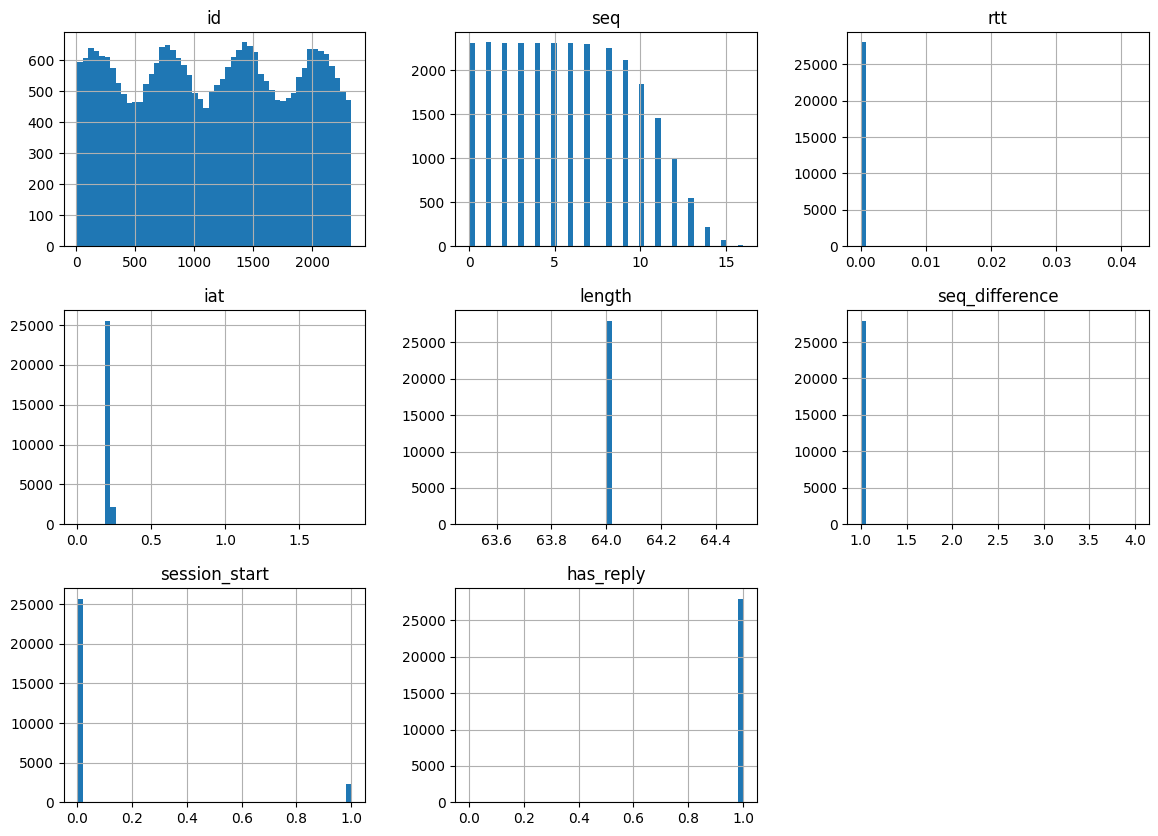

In [39]:
merged.hist(bins=50, figsize=(14,10))
plt.show()

Our data is contaminated about 5% so histograms won't show anything interesting.

## Correlation

In [40]:
correlation_matrix = merged.select_dtypes(np.number).corr()
correlation_matrix["rtt"].sort_values(ascending=False)

,rtt
rtt,1.000000
session_start,0.000941
seq,0.000750
iat,0.000498
seq_difference,-0.000447
id,-0.009789
length,NaN
has_reply,NaN


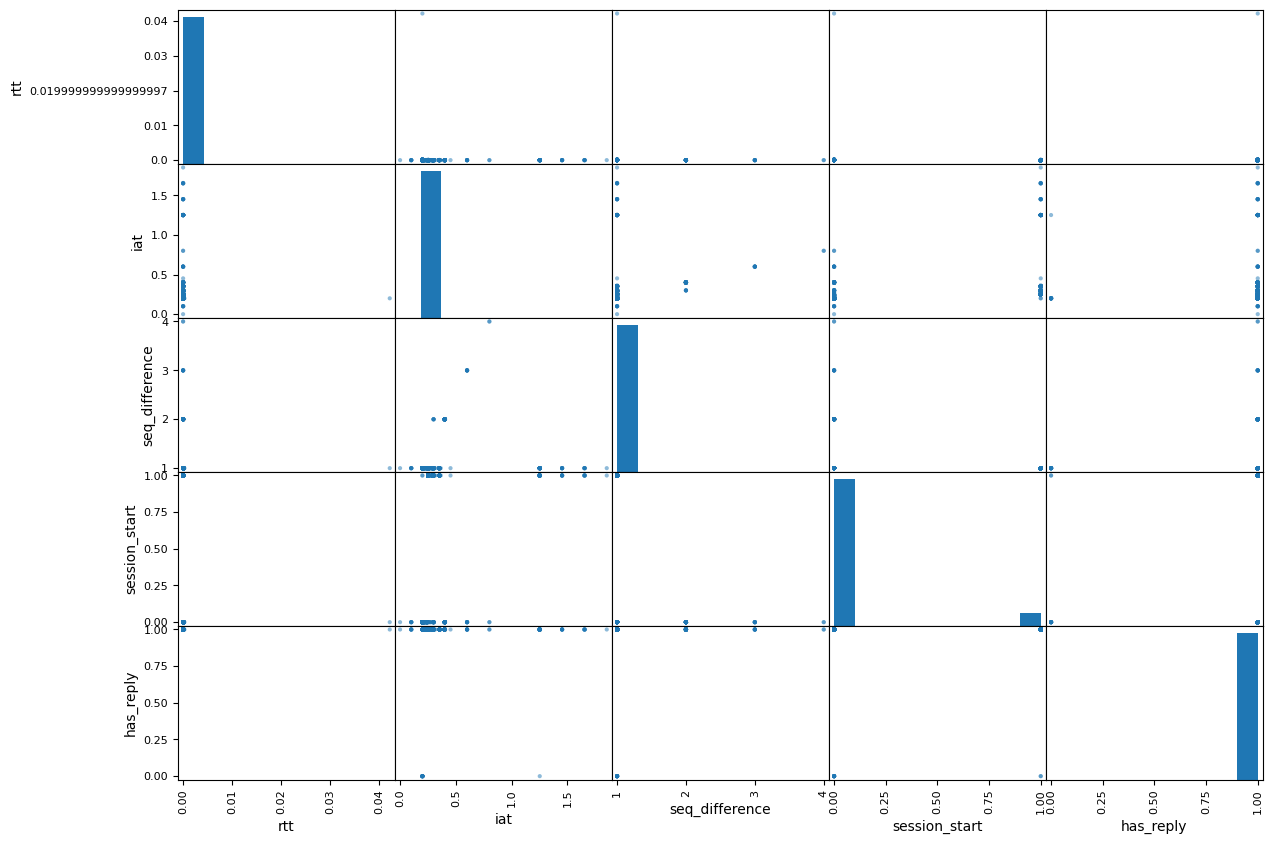

In [41]:
from pandas.plotting import scatter_matrix

scatter_matrix(merged[["rtt", "iat", "seq_difference", "session_start", "has_reply", "action"]], figsize=(14,10))
plt.show()

We don't see any correlation within our data.

## Data processing

We will create data pipeline to automize data processing for anomaly detection model.

In [128]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, RobustScaler
from sklearn.ensemble import IsolationForest

def drop_column(X, column):
  return X.drop_column[f'{column}']

def log_transform(X):
    return np.log1p(X)

def column_moving_average(X, window=10):
  if isinstance(X, np.ndarray):
        X = pd.DataFrame(X)
  return X.rolling(window=window, min_periods=1).mean()

def moving_average_pipeline(window=10):
    return make_pipeline(SimpleImputer(strategy="median"), FunctionTransformer(column_moving_average, kw_args={'window': window}, validate=False), RobustScaler())

def log_pipeline():
  return make_pipeline(SimpleImputer(strategy="median"), FunctionTransformer(log_transform), RobustScaler())

def default_pipeline():
  return make_pipeline(SimpleImputer(strategy="median"), RobustScaler())

preprocessing = ColumnTransformer([
    ("rtt_mv", moving_average_pipeline(), ["rtt"]),
    ("iat_mv", moving_average_pipeline(), ["iat"]),
    ("rtt_raw", default_pipeline(), ["rtt"]),
    ("iat_raw", default_pipeline(), ["iat"]),
    ("iat_logs", log_pipeline(), ["iat"]),
    ("rtt_logs", log_pipeline(), ["rtt"]),
    ("seq_features", RobustScaler(), ["seq_difference"]),
    ("binary", "passthrough", ["has_reply", "session_start"]),
    ("drop_unnecessary", "drop", ["id", "timestamp", "date", "length", "seq"]),
], remainder=default_pipeline())

isolation_forest = make_pipeline(
    preprocessing,
    IsolationForest(contamination=0.05, random_state=6)
)

## Training

We will train ```IsolationForest```.

In [129]:
X_anomaly_train_set = X_train_set.copy()
X_anomaly_train_set = X_anomaly_train_set.sort_values('timestamp')
X_anomaly_train_set['anomaly'] = isolation_forest.fit_predict(X_anomaly_train_set)

In [130]:
y_train_binary = np.where(y_train_set != 'NORMAL', 1, 0).astype(np.int8)
y_pred_forest_binary = np.where(X_anomaly_train_set['anomaly'] == -1, 1, 0).astype(np.int8)

In [131]:
from sklearn.metrics import precision_score, recall_score, f1_score

p = precision_score(y_train_binary, y_pred_forest_binary)
r = recall_score(y_train_binary, y_pred_forest_binary)
f1 = f1_score(y_train_binary, y_pred_forest_binary)

print(f"Precision: {p:.2f}")
print(f"Recall: {r:.2f}")
print(f"F1-Score: {f1:.2f}")

Precision: 0.02
Recall: 0.04
F1-Score: 0.03


Isolation Forest isn't doing good. Let's try other models.

In [132]:
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor

X_anomaly_train_set = X_train_set.copy()
X_anomaly_train_set = X_anomaly_train_set.sort_values('timestamp')

lof = make_pipeline(preprocessing, LocalOutlierFactor(n_neighbors=20, contamination=0.05))
y_pred_lof = lof.fit_predict(X_anomaly_train_set)
y_pred_lof_binary = np.where(y_pred_lof == -1, 1, 0).astype(np.int8)

ocsvm = make_pipeline(preprocessing, OneClassSVM(kernel='rbf', gamma='auto', nu=0.05))
ocsvm.fit(X_anomaly_train_set)
y_pred_ocsvm = ocsvm.predict(X_anomaly_train_set)
y_pred_ocsvm_binary = np.where(y_pred_ocsvm == -1, 1, 0).astype(np.int8)

p_lof = precision_score(y_train_binary, y_pred_lof_binary)
r_lof = recall_score(y_train_binary, y_pred_lof_binary)
f1_lof = f1_score(y_train_binary, y_pred_lof_binary)

print(f"LOF precision: {p_lof:.2f}")
print(f"LOF recall: {r_lof:.2f}")
print(f"LOF F1-Score: {f1_lof:.2f}")

p_ocsvm = precision_score(y_train_binary, y_pred_ocsvm_binary)
r_ocsvm = recall_score(y_train_binary, y_pred_ocsvm_binary)
f1_ocsvm = f1_score(y_train_binary, y_pred_ocsvm_binary)

print(f"OCSVM precision: {p_ocsvm:.2f}")
print(f"OCSVM recall: {r_ocsvm:.2f}")
print(f"OCSVM F1-Score: {f1_ocsvm:.2f}")

LOF precision: 0.02
LOF recall: 0.04
LOF F1-Score: 0.03
OCSVM precision: 0.03
OCSVM recall: 0.04
OCSVM F1-Score: 0.03


As we can see models that detects anomalies don't handle very well this type od data. Now we are going to train classifiers.

Binary calssifier:

In [133]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold

X_anomaly_train_set = X_train_set.copy()

forest_clf = make_pipeline(preprocessing, RandomForestClassifier(class_weight='balanced', random_state=6, n_jobs=-1))
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=6)

scoring = {'precision': 'precision','recall': 'recall','f1': 'f1'}

results = cross_validate(forest_clf, X_anomaly_train_set, y_train_binary, cv=skf, scoring=scoring, return_train_score=False)

print(f"Preccision: {results['test_precision'].mean()}")
print(f"Recall:    {results['test_recall'].mean()}")
print(f"F1-Score:  {results['test_f1'].mean()}")

Preccision: 0.7991490414855099
Recall:    0.5297548387096775
F1-Score:  0.6362917131433596


Multiclass clasifier:

In [144]:
from sklearn.metrics import make_scorer
from sklearn.metrics import classification_report

X_anomaly_train_set = X_train_set.copy()

forest_clf = make_pipeline(preprocessing, RandomForestClassifier(class_weight='balanced', random_state=6, n_jobs=-1))
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=6)

scoring_multiclass = {
    'precision': 'precision_weighted',
    'recall': 'recall_weighted',
    'f1': 'f1_weighted'
}

results = cross_validate(forest_clf, X_anomaly_train_set, y_train_set, cv=skf, scoring=scoring_multiclass, return_train_score=False)

print(f"Preccision: {results['test_precision'].mean()}")
print(f"Recall:    {results['test_recall'].mean()}")
print(f"F1-Score:  {results['test_f1'].mean()}")

forest_clf.fit(X_anomaly_train_set, y_train_set)
y_pred = forest_clf.predict(X_test_set)
print(classification_report(y_test_set, y_pred))

Preccision: 0.9779995933246463
Recall:    0.9816912190156405
F1-Score:  0.9779263213169112
              precision    recall  f1-score   support

  CORRUPTION       0.40      0.04      0.06        57
       DELAY       0.87      0.72      0.79       139
        LOSS       0.90      0.40      0.55        48
      NORMAL       0.99      1.00      0.99      8160

    accuracy                           0.98      8404
   macro avg       0.79      0.54      0.60      8404
weighted avg       0.98      0.98      0.98      8404



We can see that ```RandomForest``` are good with detecting delay (high reccal and precision), slightly worse are precision and recall for loss detecting. Model dosen't handle corruption detecting at all. It is mainly beacause of lack indicators that tell if packet is corrupted. We have strong indicators for delay (iat, rtt, moving_avg, etc.) but we lacks indicators for loss (only seq_diff) and we have almost none for corruption therefore this score.

We can assume that binary classifier is the best in this case bacuse it is only wrong in around 20% of predictions and detects around 50% of anomalies.

We can try and adjust hyperparameters for RandomForest binary classifier.

## Adjusting hiperparameters

We will adjust hiperparameter and hope scoring will be better.

In [146]:
from sklearn.model_selection import GridSearchCV

X_anomaly_train_set = X_train_set.copy()

param_grid = {
    'randomforestclassifier__n_estimators': [50, 100, 200],
    'randomforestclassifier__max_depth': [None, 10, 20],
    'randomforestclassifier__min_samples_split': [2, 5, 10],
    'randomforestclassifier__min_samples_leaf': [1, 2, 4],
    'randomforestclassifier__max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(estimator=forest_clf, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2, scoring='f1_weighted')

grid_search.fit(X_anomaly_train_set, y_train_binary)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best f1 score: {grid_search.best_score_}")

best_model = grid_search.best_estimator_
y_pred_bes_model = best_model.predict(X_test_set)
y_test_binary = np.where(y_test_set != 'NORMAL', 1, 0).astype(np.int8)
print(f"Best model precission: {precision_score(y_test_binary, y_pred_bes_model)}")
print(f"Best model recall: {recall_score(y_test_binary, y_pred_bes_model)}")
print(f"Best model f1: {f1_score(y_test_binary, y_pred_bes_model)}")

Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best parameters: {'randomforestclassifier__max_depth': None, 'randomforestclassifier__max_features': 'sqrt', 'randomforestclassifier__min_samples_leaf': 2, 'randomforestclassifier__min_samples_split': 5, 'randomforestclassifier__n_estimators': 200}
Best f1 score: 0.9805938329945059
Best model precission: 0.8258426966292135
Best model recall: 0.6024590163934426
Best model f1: 0.6966824644549763


We succesfully prepared data and trained binary classifier to detect anomalies.